<a href="https://colab.research.google.com/github/Hadia-git-sketch/ArchTechnologies_2nd_MonthTasks/blob/main/iris_flower_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📦 Loading Iris Dataset...
📊 Generating Visualizations...


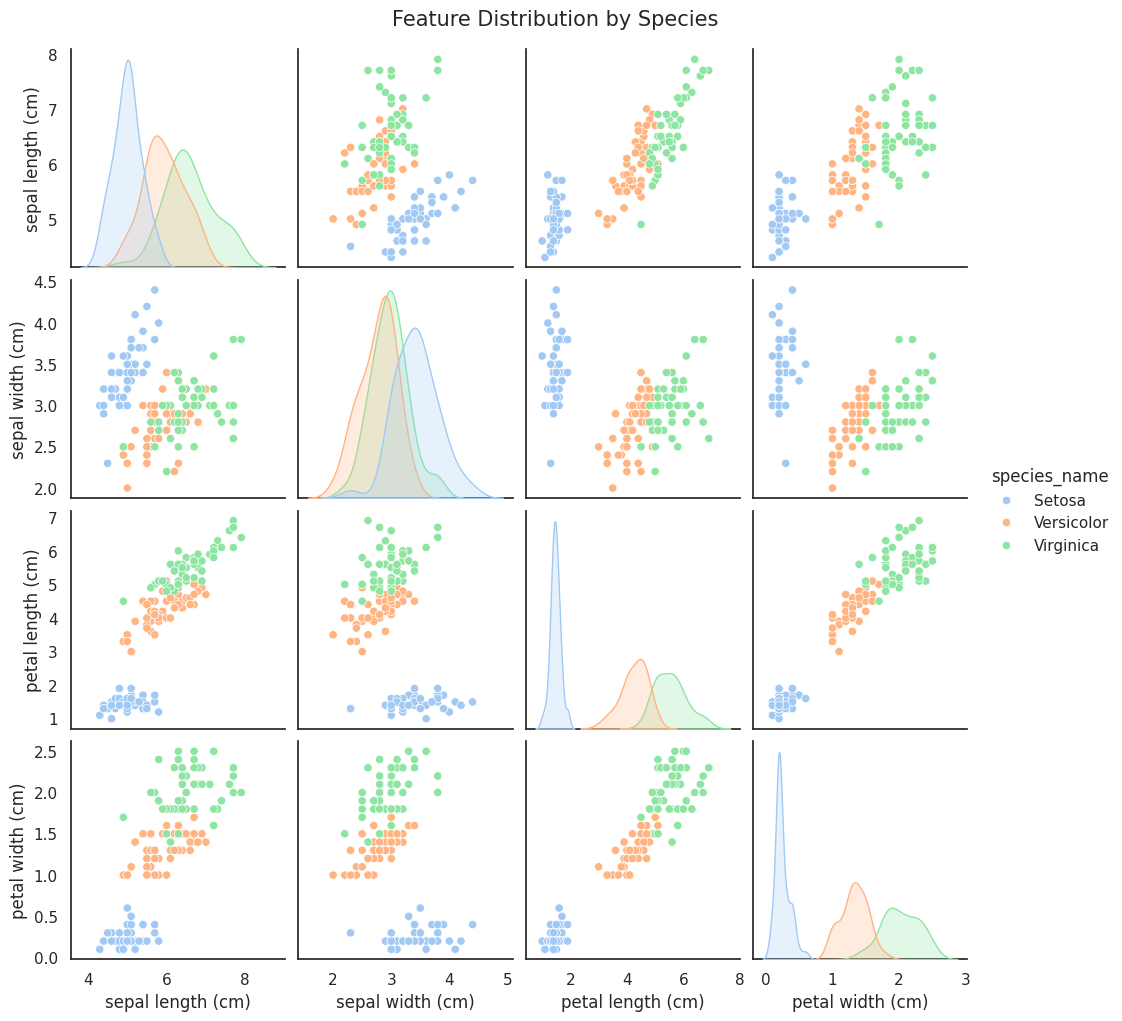

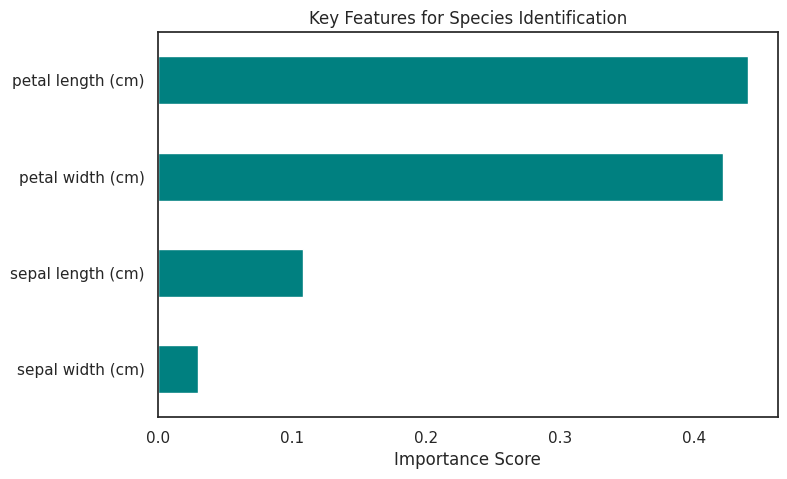


✅ Model Training Complete
📍 Accuracy Score: 100.00%

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



/tmp/ipykernel_142/1805534628.py:79: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b1535358f6d275b916.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# 🌸 IRIS FLOWER CLASSIFICATION SYSTEM

import pandas as pd
import numpy as np
import joblib
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Setting a professional aesthetic
sns.set_theme(style="white", palette="pastel")

# 1. DATA ACQUISITION
print("📦 Loading Iris Dataset...")
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
# Map numerical targets to actual names for professional display
df['species_name'] = df['species'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

# 2. EXPLORATORY DATA ANALYSIS (EDA)
print("📊 Generating Visualizations...")

# Plot A: Pairplot (The gold standard for Iris visualization)
# This shows how features interact to separate the species
sns.pairplot(df.drop('species', axis=1), hue='species_name', height=2.5)
plt.suptitle("Feature Distribution by Species", y=1.02, fontsize=15)
plt.show()



# Plot B: Feature Importance
# Let's see which part of the flower is most "telling"
X = df.drop(['species', 'species_name'], axis=1)
y = df['species']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances = pd.Series(model.feature_importances_, index=iris.feature_names)
plt.figure(figsize=(8, 5))
importances.sort_values().plot(kind='barh', color='teal')
plt.title("Key Features for Species Identification")
plt.xlabel("Importance Score")
plt.show()

# 3. PERFORMANCE EVALUATION
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Model Training Complete")
print(f"📍 Accuracy Score: {acc*100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Save the model
joblib.dump(model, 'iris_model.pkl')

# 4. PROFESSIONAL GRADIO INTERFACE
def classify_iris(sl, sw, pl, pw):
    # Load the model
    clf = joblib.load('iris_model.pkl')

    # Prediction logic
    features = np.array([[sl, sw, pl, pw]])
    prediction = clf.predict(features)[0]
    probabilities = clf.predict_proba(features)[0]

    species = iris.target_names[prediction].capitalize()
    confidence = max(probabilities) * 100

    return f"Species: {species}", f"Confidence: {confidence:.2f}%"

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🌿 Iris Species Intelligence
    ### Professional Botanical Classification Tool
    *This AI system uses a **Random Forest Classifier** to distinguish between Iris species based on precise morphological measurements.*
    """)

    with gr.Row():
        with gr.Column():
            gr.Markdown("### 📏 Sepal Measurements (cm)")
            sl = gr.Slider(4.0, 8.0, label="Sepal Length", value=5.1)
            sw = gr.Slider(2.0, 4.5, label="Sepal Width", value=3.5)

        with gr.Column():
            gr.Markdown("### 🌸 Petal Measurements (cm)")
            pl = gr.Slider(1.0, 7.0, label="Petal Length", value=1.4)
            pw = gr.Slider(0.1, 2.5, label="Petal Width", value=0.2)

    predict_btn = gr.Button("Identify Species", variant="primary")

    with gr.Row():
        label_out = gr.Textbox(label="Result", placeholder="Waiting for input...")
        conf_out = gr.Textbox(label="Model Confidence")

    predict_btn.click(
        fn=classify_iris,
        inputs=[sl, sw, pl, pw],
        outputs=[label_out, conf_out]
    )

if __name__ == "__main__":
    demo.launch(share=True)